### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import joblib
import json
import os
import yaml
import warnings
warnings.filterwarnings('ignore')

### Step 1:	Load engineered splits

In [2]:
config_file = os.path.join("..","config","config.yaml")

with open(config_file,"r") as f:
    config = yaml.safe_load(f)
    
root_path = os.path.dirname(os.path.dirname(os.path.abspath(config_file)))
engineered_path = os.path.join(root_path,config["paths"]["engineered_data"])

print("The engineered Data has be saved to: ",engineered_path)

The engineered Data has be saved to:  c:\Users\DELL\Desktop\loan-risk-system\data/engineered_data/


In [3]:
X_train_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_train_cls_engineered.csv"))
X_test_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_test_cls_engineered.csv"))
X_val_cls_engineered = pd.read_csv(os.path.join(engineered_path,"X_val_cls_engineered.csv"))
y_train_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_train_cls_engineered.csv"))
y_test_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_test_cls_engineered.csv"))
y_val_cls_engineered = pd.read_csv(os.path.join(engineered_path,"y_val_cls_engineered.csv"))

print("X_train_cls_engineered shape is: ",X_train_cls_engineered.shape)
print("X_test_cls_engineered shape is: ",X_test_cls_engineered.shape)
print("X_val_cls_engineered shape is: ",X_val_cls_engineered.shape)
print("y_train_cls_engineered shape is: ",y_train_cls_engineered.shape)
print("y_test_cls_engineered shape is: ",y_test_cls_engineered.shape)
print("y_val_cls_engineered shape is: ",y_val_cls_engineered.shape)

print("All Classification Engineered Dataset Fully Loaded...")

X_train_cls_engineered shape is:  (27577, 23)
X_test_cls_engineered shape is:  (2444, 23)
X_val_cls_engineered shape is:  (2444, 23)
y_train_cls_engineered shape is:  (27577, 1)
y_test_cls_engineered shape is:  (2444, 1)
y_val_cls_engineered shape is:  (2444, 1)
All Classification Engineered Dataset Fully Loaded...


In [4]:
X_train_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_train_reg_engineered.csv"))
X_test_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_test_reg_engineered.csv"))
X_val_reg_engineered = pd.read_csv(os.path.join(engineered_path,"X_val_reg_engineered.csv"))
y_train_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_train_reg_engineered.csv"))
y_test_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_test_reg_engineered.csv"))
y_val_reg_engineered = pd.read_csv(os.path.join(engineered_path,"y_val_reg_engineered.csv"))

print("X_train_reg_engineered shape is: ",X_train_reg_engineered.shape)
print("X_test_reg_engineered shape is: ",X_test_reg_engineered.shape)
print("X_val_reg_engineered shape is: ",X_val_reg_engineered.shape)
print("y_train_reg_engineered shape is: ",y_train_reg_engineered.shape)
print("y_test_reg_engineered shape is: ",y_test_reg_engineered.shape)
print("y_val_reg_engineered shape is: ",y_val_reg_engineered.shape)

print("All Regression Engineered Dataset Fully Loaded...")

X_train_reg_engineered shape is:  (24943, 16)
X_test_reg_engineered shape is:  (2210, 16)
X_val_reg_engineered shape is:  (2210, 16)
y_train_reg_engineered shape is:  (24943, 1)
y_test_reg_engineered shape is:  (2210, 1)
y_val_reg_engineered shape is:  (2210, 1)
All Regression Engineered Dataset Fully Loaded...


### Step 2: Define Evaluation Metrics

In [5]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,recall_score, roc_auc_score,
    r2_score, mean_squared_error, mean_absolute_error,
    silhouette_score, davies_bouldin_score,calinski_harabasz_score
)

def evaluate_classification(y_true, y_pred, y_prob=None):
    results = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'f1':        f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall':    recall_score(y_true, y_pred),
    }
    if y_prob is not None:
        results['roc_auc'] = roc_auc_score(y_true, y_prob)
    return results

def evaluate_regression(y_true, y_pred):
    results = {
        'r2':   r2_score(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae':  mean_absolute_error(y_true, y_pred)
    }
    return results

def evaluate_clustering(X, labels):
    # Handle case where only 1 cluster found
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {
            'silhouette':         None,
            'davies_bouldin':     None,
            'calinski_harabasz':  None,
            'n_clusters':         n_clusters
        }
    results = {
        'silhouette':        silhouette_score(X, labels),
        'davies_bouldin':    davies_bouldin_score(X, labels),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'n_clusters':        n_clusters
    }
    return results

print("Classification metrics defined")
print("Regression metrics defined")
print("Clustering metrics defined")

Classification metrics defined
Regression metrics defined
Clustering metrics defined


### Step 3: Handle Class Imbalance

In [6]:
# Class imbalance — Classification only
# 78.18% non-default vs 21.82% default

# Checking the current distribution
print("Class distribution:")
print(y_train_cls_engineered.value_counts(normalize=True))

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_cls_engineered),
    y=y_train_cls_engineered.values.ravel()
)

class_weight_dict = dict(zip(
    np.unique(y_train_cls_engineered.values.ravel()),
    class_weights
))
model_dir = "../models/"
# Save class weights
save_path = os.path.join(model_dir, "class_weights.pkl")
joblib.dump(class_weight_dict, save_path)


print(f"Class weights save path: {save_path}")
print(f"Class weights: {class_weight_dict}")
print("Class weights calculated")

Class distribution:
loan_status
0              0.78134
1              0.21866
Name: proportion, dtype: float64
Class weights save path: ../models/class_weights.pkl
Class weights: {0: 0.6399266719264863, 1: 2.2866500829187397}
Class weights calculated


###  Step 4: Define Baseline Models: Classification

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 3 baseline models for classification
# All use class_weight to handle imbalance

baseline_cls_models = {
    'DummyClassifier': DummyClassifier(
        strategy='most_frequent',
        random_state=42),

    'LogisticRegression': LogisticRegression(
        class_weight=class_weight_dict,
        random_state=42,
        max_iter=1000),

    'DecisionTreeClassifier': DecisionTreeClassifier(
        class_weight=class_weight_dict,
        random_state=42,
        max_depth=5)
}

print("Classification baseline models defined:")
for name in baseline_cls_models:
    print(f"  - {name}")

Classification baseline models defined:
  - DummyClassifier
  - LogisticRegression
  - DecisionTreeClassifier


### Step 5: Define Baseline Models: Regression

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

# 3 baseline models for regression
baseline_reg_models = {
    'DummyRegressor': DummyRegressor(
        strategy='mean'),

    'LinearRegression': LinearRegression(),

    'DecisionTreeRegressor': DecisionTreeRegressor(
        random_state=42,
        max_depth=5)
}

print("Regression baseline models defined:")
for name in baseline_reg_models:
    print(f"  - {name}")

Regression baseline models defined:
  - DummyRegressor
  - LinearRegression
  - DecisionTreeRegressor


### Step 6: Define Baseline Models: Clustering

In [ ]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# 3 baseline models for clustering
# We will use classification training data — no target needed
# n_clusters=3 — low/medium/high_risk_groups

baseline_clsu_models = {
    'KMeans': KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10),

    'DBSCAN': DBSCAN(
        eps=0.5,
        min_samples=5),

    'AgglomerativeClustering': AgglomerativeClustering(
        n_clusters=3)
}

print("Clustering baseline models defined:")
for name in baseline_clsu_models:
    print(f"  - {name}")

Clustering baseline models defined:
  - KMeans
  - DBSCAN
  - AgglomerativeClustering


###  Step 7: Train Baseline Models: Classification

In [ ]:
# Train all classification baseline models
# Track training time
# Store results

cls_baseline_results = {}

for name, model in baseline_cls_models.items():
    print(f"Training {name}...")
    
    # Track the starting time of the trining
    start = time.time()
    
    # Train
    model.fit(X_train_cls_engineered,y_train_cls_engineered.values.ravel())
    
    # Predict
    y_pred = model.predict(X_val_cls_engineered)
    
    # Predict probability if available
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(
            X_val_cls_engineered)[:, 1]
    
    # Evaluate
    metrics = evaluate_classification(
        y_val_cls_engineered, y_pred, y_prob)
    
    # Track time
    metrics['train_time'] = round(time.time() - start, 4)
    
    cls_baseline_results[name] = metrics
    print(f"Done in {metrics['train_time']}s")

print("\nAll classification baselines trained\n")

print("Baseline Model Training Report: \n",cls_baseline_results)

Training DummyClassifier...
Done in 0.0363s
Training LogisticRegression...
Done in 0.1256s
Training DecisionTreeClassifier...
Done in 0.2741s

All classification baselines trained

Baseline Model Training Report: 
 {'DummyClassifier': {'accuracy': 0.7819148936170213, 'f1': 0.0, 'precision': 0.0, 'recall': 0.0, 'roc_auc': 0.5, 'train_time': 0.0363}, 'LogisticRegression': {'accuracy': 0.8019639934533551, 'f1': 0.6271186440677967, 'precision': 0.5320261437908497, 'recall': 0.7636022514071295, 'roc_auc': 0.8630079828150051, 'train_time': 0.1256}, 'DecisionTreeClassifier': {'accuracy': 0.8764320785597381, 'f1': 0.7118320610687022, 'precision': 0.7242718446601941, 'recall': 0.699812382739212, 'roc_auc': 0.870268702083229, 'train_time': 0.2741}}


###  Step 8: Train Baseline Models: Regression

In [ ]:
# Train all regression baseline models
# Track training time
# Store results

reg_baseline_results = {}

for name, model in baseline_reg_models.items():
    print(f"Training {name}...")
    
    start = time.time()
    
    model.fit(X_train_reg_engineered,
              y_train_reg_engineered.values.ravel())
    
    y_pred = model.predict(X_val_reg_engineered)
    
    metrics = evaluate_regression(
        y_val_reg_engineered, y_pred)
    
    metrics['train_time'] = round(time.time() - start, 4)
    
    reg_baseline_results[name] = metrics
    print(f"Done in {metrics['train_time']}s")

print("\nAll regression baselines trained")
print("\nBaseline Regression Results:")
print(reg_baseline_results)

Training DummyRegressor...
Done in 0.007s
Training LinearRegression...
Done in 0.1003s
Training DecisionTreeRegressor...
Done in 0.298s

All regression baselines trained

Baseline Regression Results:
{'DummyRegressor': {'r2': -0.00043336110073766143, 'rmse': 3.3505357025560203, 'mae': 2.800183154606076, 'train_time': 0.007}, 'LinearRegression': {'r2': 0.8826327587086026, 'rmse': 1.1476081282083153, 'mae': 0.9045309580513794, 'train_time': 0.1003}, 'DecisionTreeRegressor': {'r2': 0.9095790687259651, 'rmse': 1.0072903076162703, 'mae': 0.8021892341741103, 'train_time': 0.298}}


### Step 9: Train Baseline Models: Clustering

In [ ]:
# Train all clustering baseline models
# Use X_train_cls_engineered — no target needed
# Track training time
# Store results

cluster_baseline_results = {}

for name, model in baseline_clsu_models.items():
    print(f"Training {name}...")
    
    start = time.time()
    
    labels = model.fit_predict(X_train_cls_engineered)
    
    metrics = evaluate_clustering(
        X_train_cls_engineered, labels)
    
    metrics['train_time'] = round(time.time() - start, 4)
    
    cluster_baseline_results[name] = metrics
    print(f"Done in {metrics['train_time']}s")

print("\nAll clustering baselines trained")
print("\nBaseline Clustering Results:")
print(cluster_baseline_results)

Training KMeans...
Done in 20.0142s
Training DBSCAN...
Done in 14.9113s
Training AgglomerativeClustering...
Done in 59.15s

All clustering baselines trained

Baseline Clustering Results:
{'KMeans': {'silhouette': 0.1478558473417366, 'davies_bouldin': 2.3774538610575298, 'calinski_harabasz': 2480.867570568778, 'n_clusters': 3, 'train_time': 20.0142}, 'DBSCAN': {'silhouette': -0.4250676213697093, 'davies_bouldin': 1.7363101568117665, 'calinski_harabasz': 4.074999485547203, 'n_clusters': 102, 'train_time': 14.9113}, 'AgglomerativeClustering': {'silhouette': 0.15532336950490705, 'davies_bouldin': 2.46864117947787, 'calinski_harabasz': 1910.2080737000429, 'n_clusters': 3, 'train_time': 59.15}}


###  Step 10: Evaluate Classification

In [ ]:
# Classification

print("CLASSIFICATION BASELINE RESULTS")

cls_results_df = pd.DataFrame(cls_baseline_results).T
cls_results_df = cls_results_df.round(4)
print(cls_results_df)

print("\nBest Model by F1:")
best_f1 = cls_results_df['f1'].idxmax()
print(f"  {best_f1} — F1: {cls_results_df.loc[best_f1, 'f1']}")

print("\nBest Model by ROC-AUC:")
best_auc = cls_results_df['roc_auc'].idxmax()
print(f"  {best_auc} — ROC-AUC: {cls_results_df.loc[best_auc, 'roc_auc']}")

CLASSIFICATION BASELINE RESULTS
                        accuracy      f1  precision  recall  roc_auc  \
DummyClassifier           0.7819  0.0000     0.0000  0.0000   0.5000   
LogisticRegression        0.8020  0.6271     0.5320  0.7636   0.8630   
DecisionTreeClassifier    0.8764  0.7118     0.7243  0.6998   0.8703   

                        train_time  
DummyClassifier             0.0363  
LogisticRegression          0.1256  
DecisionTreeClassifier      0.2741  

Best Model by F1:
  DecisionTreeClassifier — F1: 0.7118

Best Model by ROC-AUC:
  DecisionTreeClassifier — ROC-AUC: 0.8703


### Step 11: Evaluate: Regression

In [ ]:
# Regression

print("REGRESSION BASELINE RESULTS")

reg_results_df = pd.DataFrame(reg_baseline_results).T
reg_results_df = reg_results_df.round(4)
print(reg_results_df)

print("\nBest Model by R2:")
best_r2 = reg_results_df['r2'].idxmax()
print(f"  {best_r2} — R2: {reg_results_df.loc[best_r2, 'r2']}")

REGRESSION BASELINE RESULTS
                           r2    rmse     mae  train_time
DummyRegressor        -0.0004  3.3505  2.8002      0.0070
LinearRegression       0.8826  1.1476  0.9045      0.1003
DecisionTreeRegressor  0.9096  1.0073  0.8022      0.2980

Best Model by R2:
  DecisionTreeRegressor — R2: 0.9096


### Step 12: Evaluate: Clustering

In [ ]:
# Clustering

print("CLUSTERING BASELINE RESULTS")

cluster_results_df = pd.DataFrame(cluster_baseline_results).T
cluster_results_df = cluster_results_df.round(4)
print(cluster_results_df)

print("\nBest Model by Silhouette:")
# Exclude DBSCAN — too many clusters
valid = cluster_results_df[cluster_results_df['n_clusters'] <= 10]
best_sil = valid['silhouette'].idxmax()
print(f"  {best_sil} — Silhouette: {valid.loc[best_sil, 'silhouette']}")

CLUSTERING BASELINE RESULTS
                         silhouette  davies_bouldin  calinski_harabasz  \
KMeans                       0.1479          2.3775          2480.8676   
DBSCAN                      -0.4251          1.7363             4.0750   
AgglomerativeClustering      0.1553          2.4686          1910.2081   

                         n_clusters  train_time  
KMeans                          3.0     20.0142  
DBSCAN                        102.0     14.9113  
AgglomerativeClustering         3.0     59.1500  

Best Model by Silhouette:
  AgglomerativeClustering — Silhouette: 0.1553


### Step 13: Compare All Baseline Results (with plots)

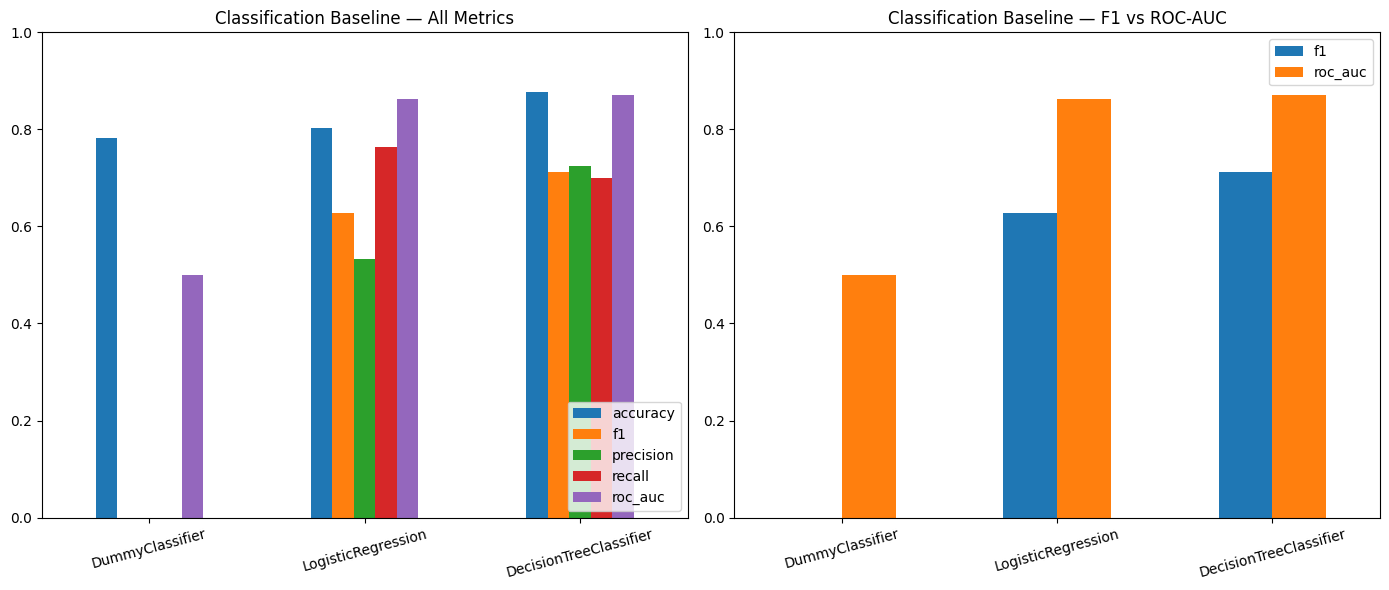

In [ ]:
# Bar plot comparing all classification models
# Show all metrics side by side

metrics_cls = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 — All metrics
cls_results_df[metrics_cls].plot(
    kind='bar', ax=axes[0])
axes[0].set_title('Classification Baseline — All Metrics')
axes[0].set_xticklabels(cls_results_df.index, rotation=15)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0, 1)

# Plot 2 — F1 and ROC-AUC only
cls_results_df[['f1', 'roc_auc']].plot(
    kind='bar', ax=axes[1])
axes[1].set_title('Classification Baseline — F1 vs ROC-AUC')
axes[1].set_xticklabels(cls_results_df.index, rotation=15)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

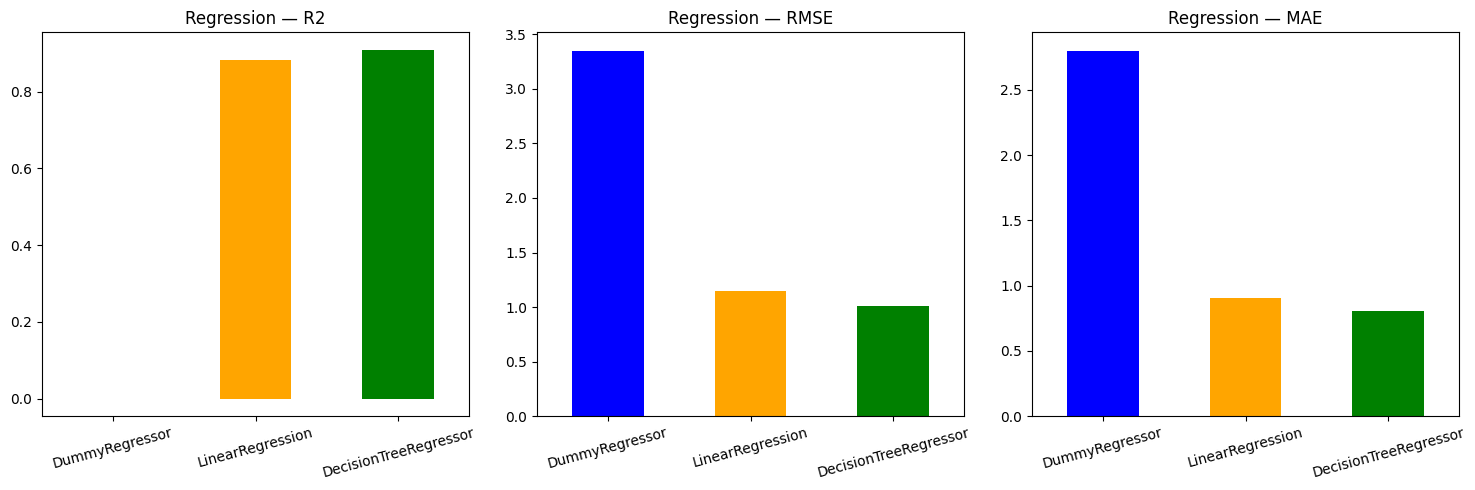

In [ ]:
# Bar plot comparing all Regression models
# Show all metrics side by side

metrics_reg = ["r2", "rmse", "mae"]

# Regression — separate subplots per metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics_reg = ['r2', 'rmse', 'mae']
for i, metric in enumerate(metrics_reg):
    reg_results_df[metric].plot(
        kind='bar', ax=axes[i], color=['blue', 'orange', 'green'])
    axes[i].set_title(f'Regression — {metric.upper()}')
    axes[i].set_xticklabels(reg_results_df.index, rotation=15)

plt.tight_layout()
plt.show()

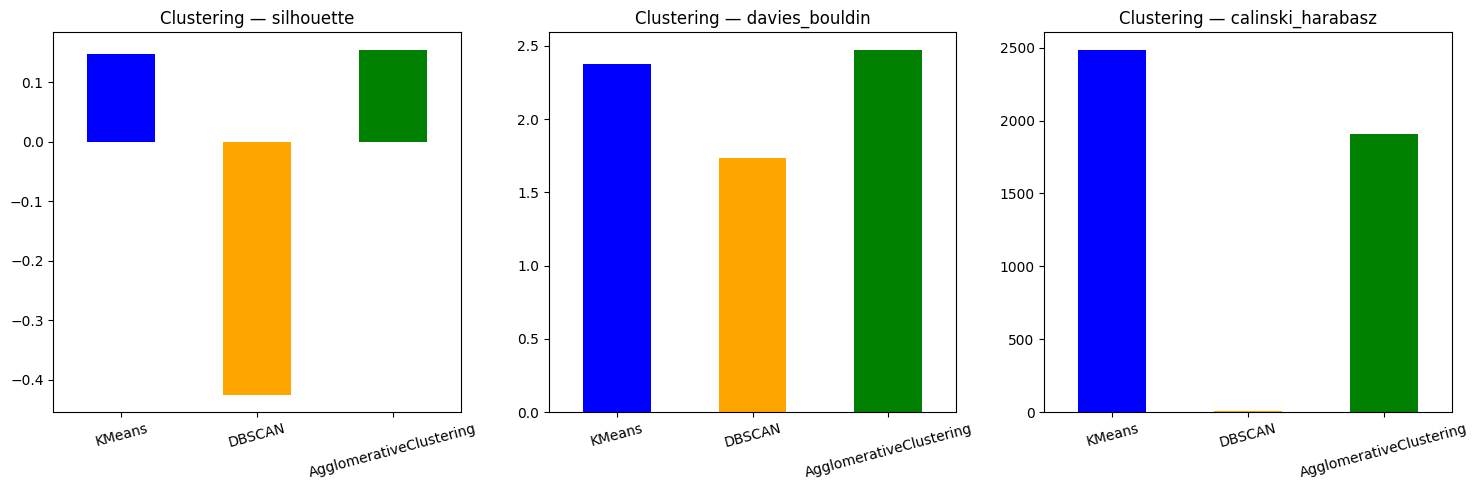

In [ ]:
# Bar plot comparing all Clustering models
# Show all metrics side by side

metrics_clut = ["silhouette", "davies_bouldin", "calinski_harabasz"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_cluster = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
for i, metric in enumerate(metrics_cluster):
    cluster_results_df[metric].plot(
        kind='bar', ax=axes[i], color=['blue', 'orange', 'green'])
    axes[i].set_title(f'Clustering — {metric}')
    axes[i].set_xticklabels(cluster_results_df.index, rotation=15)

plt.tight_layout()
plt.show()

### Step 15: Save Baseline Results

In [ ]:
baseline_results = {
    'classification': cls_baseline_results,
    'regression':     reg_baseline_results,
    'clustering':     cluster_baseline_results
}

# Save as JSON
with open('../models/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=4)

# Save as CSV
cls_results_df.to_csv('../models/baseline_cls_results.csv')
reg_results_df.to_csv('../models/baseline_reg_results.csv')
cluster_results_df.to_csv('../models/baseline_cluster_results.csv')

print("Baseline results saved")

Baseline results saved


### Step 16: Document Report

In [ ]:
# see report in loan-risk-system\docs\baseline_model_report.md